In [2]:
import numpy as np
from edge_pydb import EdgeTable
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from edge_pydb.plotting import gridplot

In [3]:
tglobal = EdgeTable('ecalifa_leda.csv', cols = ['Name', 'ledaRA', 'ledaDE', 'ledaPA', 'ledaIncl', 'ledaD25', 'ledaAxIncl'])

In [4]:
tglobal

Name,ledaRA,ledaDE,ledaPA,ledaIncl,ledaD25,ledaAxIncl
,deg,deg,deg,deg,arcmin,deg
str27,float64,float64,float64,float64,float64,float64
PRCC-02,4.9691415,22.4776812,40.0,45.87,0.40,45.5
iPTF14gnl,5.951298,-3.8557556,88.0,59.81,0.60,57.6
GIN010,10.727784,-9.2304037,84.86,90.0,0.95,77.1
PTF12ikt,18.6827205,0.2860168,121.92,54.54,0.56,53.8
LSQ12gef,25.1406255,18.5112778,60.5,62.94,0.49,57.3
PGC74050,29.56575,36.3482778,5.0,26.36,0.48,26.0
PGC1481751,30.420042,15.3311389,160.5,41.47,0.46,41.1
SN2012fk_c,37.7170005,22.4757222,70.0,--,--,--


In [5]:
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u

#wrapper function to compute galaxy center

def compute_galaxy_center(galname, fluxtab, wcs=None, clipedge=True, pad=0):
    #select rows corresponding to chosen galaxy
    galdata = fluxtab[fluxtab['Name'] == galname]

    try: #use RA/DEC from LEDA and WCS to get pixel coords
        ra = float(galdata['ledaRA'][0])
        dec = float(galdata['ledaDE'][0])
        coord = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)
        ix_full, iy_full = wcs.world_to_pixel(coord)

    except KeyError: #resort to using median values as a center estimate
        ix_full = np.median(galdata['ix'])
        iy_full = np.median(galdata['iy'])

    #define the bounding box of the galaxy
    ix_min, ix_max = np.min(galdata['ix']), np.max(galdata['ix'])
    iy_min, iy_max = np.min(galdata['iy']), np.max(galdata['iy'])

    if clipedge: 
        clip_offset = 1 #accounts for default clip of 1 pixel/edge 
    else: 
        clip_offset = 0

    #convert into coords relative to galaxy's panel
    ix_panel = ix_full - ix_min + clip_offset + pad
    iy_panel = iy_full - iy_min + clip_offset + pad

    #will return the galaxy's center using a panel-local pixel scale
    return ix_panel, iy_panel

In [6]:
#example galaxy to test/practice with
import numpy as np
from edge_pydb import EdgeTable
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from edge_pydb.plotting import gridplot

sspcols  = ['Name','ix','iy','sigstar','fe_medflx']
fluxcols = ['Name','ix','iy','flux_[OIII]5007','flux_Hbeta','flux_Halpha',
            'flux_[NII]6583','EW_Halpha','flux_sigsfr0','e_flux_sigsfr0',
            'flux_sigsfr_corr','flux_sigsfr_adopt','BPT','ZOH']

fluxtab = EdgeTable('edge_carma_allpix.pipe3d.hdf5', path='flux_elines', cols=fluxcols)
ssptab  = EdgeTable('edge_carma_allpix.pipe3d.hdf5', path='SSP', cols=sspcols)

fluxtab.join(ssptab, keys=['Name', 'ix', 'iy'])

galname = 'NGC4047'

plt.rcParams.update({'font.size': 24})
axes = gridplot(edgetab=fluxtab, 
                gallist=[galname], 
                columnlist=['flux_[NII]6583'], 
                plotstyle='image', 
                clipedge=True, 
                pad=0,  
                vshow=True,
                nx=1, ny=1)

plt.show()

TypeError: Cannot compare structured arrays unless they have a common dtype.  I.e. `np.result_type(arr1, arr2)` must be defined.

In [ ]:
#return the center coords of the galaxy 
ix_center, iy_center = compute_galaxy_center(galname, fluxtab, wcs=None, clipedge=True, pad=0)
print(ix_center, iy_center)

39.0 36.5


In [5]:
import numpy as np
from edge_pydb import EdgeTable
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from edge_pydb.plotting import gridplot

sspcols  = ['Name','ix','iy', 'ra_abs', 'dec_abs', 'sigstar','fe_medflx']
ssptab  = EdgeTable('edge_carma_allpix.pipe3d.hdf5', path='SSP', cols=sspcols)

galtab = (ssptab['Name'] == 'NGC4047')
sc = SkyCoord(ra=ssptab[galtab]['ra_abs'], dec=ssptab[galtab]['dec_abs'], frame='fk5')
print(sc)
  

<SkyCoord (FK5: equinox=J2000.000): (ra, dec) in deg
    [(180.72649, 48.62711 ), (180.72649, 48.627384),
     (180.72649, 48.627663), ..., (180.69455, 48.646275),
     (180.69455, 48.646553), (180.69455, 48.64683 )]>


In [6]:
tglobal = EdgeTable('ecalifa_leda.csv', cols = ['Name', 'ledaRA', 'ledaDE', 'ledaPA', 'ledaIncl', 'ledaD25', 'ledaAxIncl'])
galdata = tglobal[tglobal['Name'] == 'NGC4047']
ra = float(galdata['ledaRA'][0])
dec = float(galdata['ledaDE'][0])
ref_coord = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)
dist = ref_coord.separation(sc)
print(dist)
print(np.min(dist), np.argmin(dist))
min_index = np.argmin(dist)

[0d00m49.13559097s 0d00m48.47685007s 0d00m47.82977197s ...
 0d00m53.49917007s 0d00m54.18663706s 0d00m54.87544904s]
0d00m00.46923567s 2697


In [7]:
ssptab[galtab]['ix'][min_index]
ssptab[galtab]['iy'][min_index]

np.int32(33)

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from astropy.coordinates import SkyCoord
import astropy.units as u
from edge_pydb import EdgeTable

In [9]:
#loading in relevant columns from hdf5 files
sspcols = ['Name','ix','iy','ra_abs','dec_abs','sigstar','fe_medflx']
ssptab = EdgeTable('edge_carma_allpix.pipe3d.hdf5', path = 'SSP', cols = sspcols)
#loading in global dataset (csv)
tglobal = EdgeTable('ecalifa_leda.csv', cols=['Name','ledaRA','ledaDE','ledaPA','ledaIncl','ledaD25','ledaAxIncl'])

In [9]:
#find the nearest pixel to the given RA/Dec
def get_nearest_pixel(ssptab, galaxy_name, catalog_ra, catalog_dec):
    galaxy_rows = ssptab[ssptab['Name'] == galaxy_name]
    pixel_coords = SkyCoord(ra = np.array(galaxy_rows['ra_abs']) * u.deg,
                            dec = np.array(galaxy_rows['dec_abs']) * u.deg, frame = 'fk5')
    catalog_coord = SkyCoord(ra = catalog_ra * u.deg, dec = catalog_dec * u.deg, frame = 'fk5')
    separations = catalog_coord.separation(pixel_coords)
    nearest_idx = np.argmin(separations)
    return (int(galaxy_rows['ix'][nearest_idx]), int(galaxy_rows['iy'][nearest_idx]), separations[nearest_idx].to(u.arcsec).value)
galaxy_rows = ssptab[ssptab['Name'] == 'NGC4047']
SkyCoord(ra = np.array(galaxy_rows['ra_abs']) * u.deg, dec = np.array(galaxy_rows['dec_abs']) * u.deg, frame = 'fk5')

<SkyCoord (FK5: equinox=J2000.000): (ra, dec) in deg
    [(180.72649, 48.62711 ), (180.72649, 48.627384),
     (180.72649, 48.627663), ..., (180.69455, 48.646275),
     (180.69455, 48.646553), (180.69455, 48.64683 )]>

In [13]:
#compute center, nearest pixel, and offset
galdata = tglobal[tglobal['Name'] == 'IC0480']
ra = float(galdata['ledaRA'][0])
dec = float(galdata['ledaDE'][0])

ix, iy, offset_arcsec = get_nearest_pixel(ssptab, 'IC0480', ra, dec)
print("Nearest pixel indices:", ix, iy)
print("Offset (arcsec):", offset_arcsec)

Nearest pixel indices: 34 37
Offset (arcsec): 0.09289710405495606


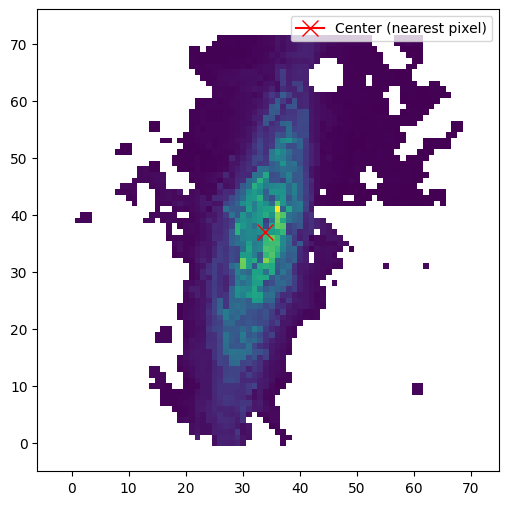

In [15]:
#plot marker at pixel nearest to true center
from edge_pydb.plotting import imarrayplot
import matplotlib.pyplot as plt

galmask = ssptab['Name'] == 'IC0480'
x = ssptab[galmask]['ix']
y = ssptab[galmask]['iy']
sigstar = ssptab[galmask]['sigstar']
fig, ax = plt.subplots(figsize = (6, 6))
img, xlims, ylims = imarrayplot(x, y, sigstar, axes = ax, clipedge = True)
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.plot(ix, iy, marker = 'x', color = 'red', markersize = 12, label = 'Center (nearest pixel)')
ax.legend()
plt.show()

In [16]:
#function to overlay center marker on galaxy plot

def overlay_galaxy_with_marker(ax, ssptab, galname, catalog_ra, catalog_dec,
                               marker_style = 'x', marker_color = 'black', marker_size = 20,
                               marker_edgewidth = 3,
                               plot_column = 'sigstar', cmap = 'jet'):
    galaxy_rows = ssptab[ssptab['Name'] == galname]

    from edge_pydb.plotting import imarrayplot
    img, xlims, ylims = imarrayplot(x = galaxy_rows['ix'],
                                    y = galaxy_rows['iy'],
                                    imval = galaxy_rows[plot_column],
                                    axes = ax,
                                    cmap = cmap)

    ax.set_xlim(xlims)
    ax.set_ylim(ylims)
    ax.set_aspect('equal')

    ix, iy, _ = get_nearest_pixel(ssptab, galname, catalog_ra, catalog_dec)

    ax.plot(ix, iy, marker = marker_style,
            color = marker_color,
            markersize = marker_size,
            markeredgewidth = marker_edgewidth)

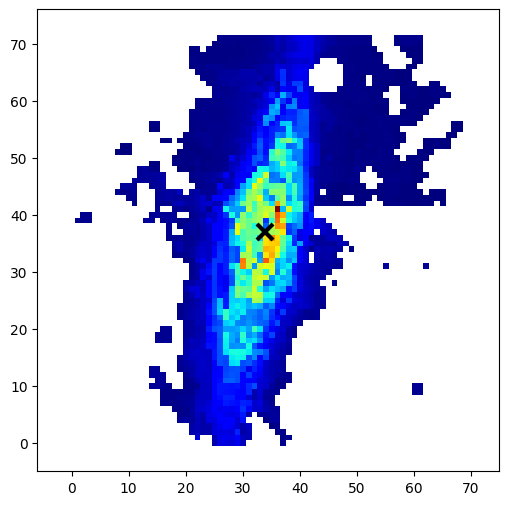

In [17]:
#testing marker overlay function
ra_ref = float(galdata['ledaRA'][0])
dec_ref = float(galdata['ledaDE'][0])
fig, ax = plt.subplots(figsize = (6, 6))
overlay_galaxy_with_marker(ax, ssptab, 'IC0480', ra_ref, dec_ref,
                           marker_style = 'x', marker_color = 'black', marker_size = 12,
                           plot_column = 'sigstar', cmap = 'jet')
plt.show()